In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
import os
import zipfile
import urllib.request

dataset_url = "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip"
zip_path = "/content/dataset-resized.zip"

print("Downloading dataset...")

urllib.request.urlretrieve(dataset_url, zip_path)

print("Download complete!")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Download complete!
Dataset extracted successfully!


In [4]:
# ==========================================
# STEP 3: Load and Check Waste Categories
# ==========================================

import os

# Dataset ka path define kar rahe hain
dataset_path = "/content/dataset-resized"

# Sirf actual waste category folders ko select kar rahe hain
# Hidden files jaise .DS_Store ko ignore karenge
classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
    and not folder.startswith(".")
])

# Waste categories display karna
print("Waste Categories:")

for i, cls in enumerate(classes):
    print(i, "→", cls)

# Total categories count karna
print("\nTotal Categories:", len(classes))

Waste Categories:
0 → cardboard
1 → glass
2 → metal
3 → paper
4 → plastic
5 → trash

Total Categories: 6


In [5]:
# ==========================================
# STEP 4: Count Images in Each Category
# ==========================================

# Har waste category ke folder mein images count karna
for cls in classes:

    # Current category ka folder path
    folder_path = os.path.join(dataset_path, cls)

    # Sirf image files ko count karna
    image_count = len([
        file for file in os.listdir(folder_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    # Category aur images ki total count display karna
    print(f"{cls}: {image_count} images")

cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


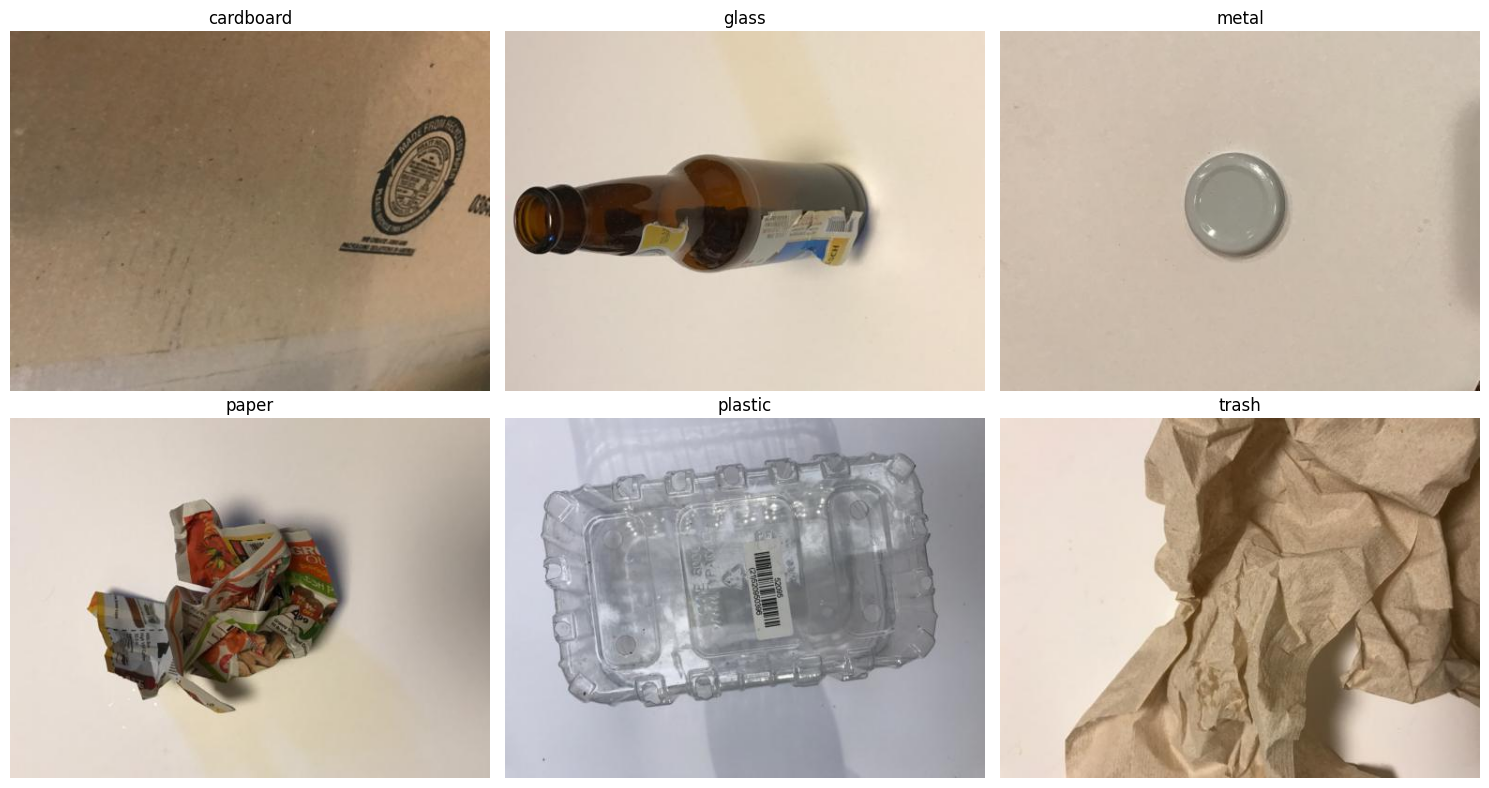

In [6]:
# ==========================================
# STEP 5: Display Sample Images
# ==========================================

import random
from PIL import Image

# Har waste category se ek random image display karna
plt.figure(figsize=(15, 8))

for i, cls in enumerate(classes):

    # Current category ka folder
    folder_path = os.path.join(dataset_path, cls)

    # Folder se image files lena
    image_files = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Random image select karna
    random_image = random.choice(image_files)

    # Image ka complete path
    image_path = os.path.join(folder_path, random_image)

    # Image load karna
    image = Image.open(image_path)

    # Image display karna
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

# Layout ko clean banana
plt.tight_layout()

# Images display karna
plt.show()

In [7]:
# ==========================================
# STEP 6: Create Training, Validation
# and Testing Datasets
# ==========================================

import tensorflow as tf

# Images ka size fix kar rahe hain
# Deep learning model ko same size ki images chahiye
IMG_SIZE = (224, 224)

# Ek batch mein 32 images process hongi
BATCH_SIZE = 32

# Random seed fix kar rahe hain
# Isse har baar same type ka split milega
SEED = 42

# Dataset ka path
dataset_path = "/content/dataset-resized"

# ------------------------------------------
# Training Dataset - 80%
# ------------------------------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ------------------------------------------
# Temporary Validation + Testing Dataset
# Remaining 20%
# ------------------------------------------

remaining_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Dataset ke class names save karna
class_names = train_dataset.class_names

print("\nWaste Categories:")
print(class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.

Waste Categories:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:
# ==========================================
# STEP 7: Split Remaining Data into
# Validation and Testing Datasets
# ==========================================

# Remaining dataset ke total batches count karna
total_batches = tf.data.experimental.cardinality(remaining_dataset).numpy()

print("Total remaining batches:", total_batches)

# Remaining data ka aadha validation ke liye lena
validation_batches = total_batches // 2

# Validation dataset banana
validation_dataset = remaining_dataset.take(validation_batches)

# Bacha hua data testing ke liye lena
test_dataset = remaining_dataset.skip(validation_batches)

# Dataset information display karna
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Total remaining batches: 16
Validation batches: 8
Testing batches: 8


In [9]:
# ==========================================
# STEP 8: Data Augmentation and Preprocessing
# ==========================================

# Data augmentation ke liye Keras Sequential model
# banaya ja raha hai
data_augmentation = tf.keras.Sequential([

    # Image ko randomly horizontally flip karna
    tf.keras.layers.RandomFlip("horizontal"),

    # Image ko randomly rotate karna
    tf.keras.layers.RandomRotation(0.1),

    # Image ko randomly zoom karna
    tf.keras.layers.RandomZoom(0.1),
])

# Dataset ko faster training ke liye optimize karna
AUTOTUNE = tf.data.AUTOTUNE

# Training dataset ko optimize karna
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# Validation dataset ko optimize karna
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Testing dataset ko optimize karna
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Data augmentation and preprocessing setup completed!")

Data augmentation and preprocessing setup completed!


In [10]:
# ==========================================
# STEP 9: Build Deep Learning Model
# Using Transfer Learning - MobileNetV2
# ==========================================

# MobileNetV2 ko TensorFlow se import karna
from tensorflow.keras.applications import MobileNetV2

# Model ke liye input image size define karna
IMG_SHAPE = (224, 224, 3)

# Pre-trained MobileNetV2 model load karna
# ImageNet weights use kar rahe hain
# include_top=False ka matlab original classifier remove karna
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet"
)

# Starting mein pre-trained model ke weights ko freeze karna
# Isse hum pehle se learned features ko preserve karenge
base_model.trainable = False

# ==========================================
# New Classification Layers
# ==========================================

# Apna classification model banana
model = tf.keras.Sequential([

    # Data augmentation
    data_augmentation,

    # MobileNetV2 ke required preprocessing
    tf.keras.layers.Rescaling(
        1.0 / 127.5,
        offset=-1
    ),

    # Pre-trained MobileNetV2
    base_model,

    # Feature maps ko single vector mein convert karna
    tf.keras.layers.GlobalAveragePooling2D(),

    # Overfitting kam karne ke liye Dropout
    tf.keras.layers.Dropout(0.2),

    # 6 waste categories ke liye output layer
    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

# Model ko compile karna
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model ki complete structure dekhna
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# ==========================================
# STEP 10: Build and Verify the Model
# ==========================================

# Training dataset se ek batch lena
for images, labels in train_dataset.take(1):

    # Ek batch ki image shape check karna
    print("Input image shape:", images.shape)

    # Model ko ek batch par run karke build karna
    predictions = model(images)

    # Model ke output ki shape check karna
    print("Model output shape:", predictions.shape)

# Model ki complete structure dobara display karna
model.summary()

Input image shape: (32, 224, 224, 3)
Model output shape: (32, 6)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 1280)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 6)                │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# ==========================================
# STEP 11: Train the Deep Learning Model
# ==========================================

# Training ke liye number of epochs
# Har epoch mein model poore training dataset ko ek baar dekhega
EPOCHS = 15

# Model training start karna
history = model.fit(

    # Training dataset
    train_dataset,

    # Validation dataset se performance check karna
    validation_data=validation_dataset,

    # Total training rounds
    epochs=EPOCHS
)

print("\nModel training completed!")

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.5252 - loss: 1.2224 - val_accuracy: 0.7070 - val_loss: 0.8233
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7300 - loss: 0.7237 - val_accuracy: 0.7734 - val_loss: 0.6554
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.7755 - loss: 0.5895 - val_accuracy: 0.7930 - val_loss: 0.5712
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.8121 - loss: 0.5229 - val_accuracy: 0.8203 - val_loss: 0.4800
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.8239 - loss: 0.4849 - val_accuracy: 0.8125 - val_loss: 0.5605
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8249 - loss: 0.4598 - val_accuracy: 0.8438 - val_loss: 0.4479
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8432 - loss: 0.4226 - val_accuracy: 0.8281 - val_loss: 0.5241
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8566 - loss: 0.3962 - val_accuracy: 0.8320 - 

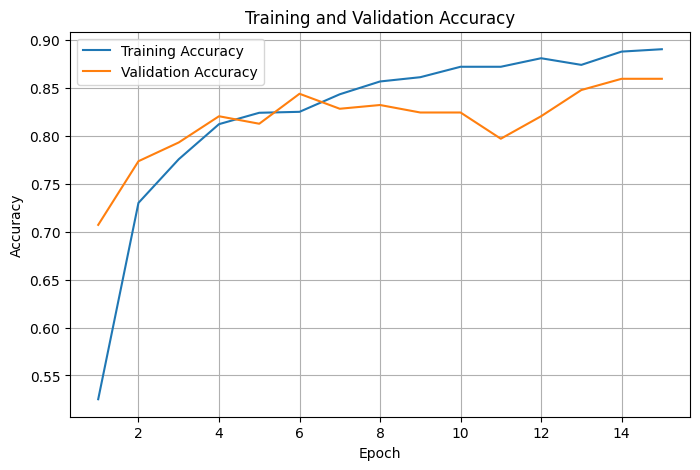

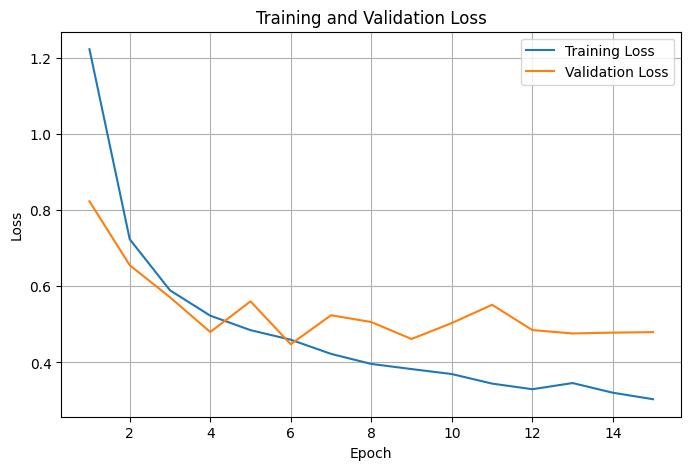

In [13]:
# ==========================================
# STEP 12: Plot Accuracy and Loss Graphs
# ==========================================

# Training history se accuracy values lena
train_accuracy = history.history["accuracy"]

# Validation accuracy values lena
validation_accuracy = history.history["val_accuracy"]

# Training loss values lena
train_loss = history.history["loss"]

# Validation loss values lena
validation_loss = history.history["val_loss"]

# Total epochs ki list banana
epochs_range = range(1, len(train_accuracy) + 1)

# ==========================================
# Accuracy Graph
# ==========================================

plt.figure(figsize=(8, 5))

# Training accuracy plot karna
plt.plot(
    epochs_range,
    train_accuracy,
    label="Training Accuracy"
)

# Validation accuracy plot karna
plt.plot(
    epochs_range,
    validation_accuracy,
    label="Validation Accuracy"
)

# Graph ka title
plt.title("Training and Validation Accuracy")

# X-axis label
plt.xlabel("Epoch")

# Y-axis label
plt.ylabel("Accuracy")

# Legend display karna
plt.legend()

# Grid display karna
plt.grid(True)

# Graph show karna
plt.show()


# ==========================================
# Loss Graph
# ==========================================

plt.figure(figsize=(8, 5))

# Training loss plot karna
plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss"
)

# Validation loss plot karna
plt.plot(
    epochs_range,
    validation_loss,
    label="Validation Loss"
)

# Graph ka title
plt.title("Training and Validation Loss")

# X-axis label
plt.xlabel("Epoch")

# Y-axis label
plt.ylabel("Loss")

# Legend display karna
plt.legend()

# Grid display karna
plt.grid(True)

# Graph show karna
plt.show()

In [14]:
# ==========================================
# STEP 13: Evaluate Model on Test Dataset
# ==========================================

# Test dataset par trained model ki performance check karna
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

# Test accuracy display karna
print("\nFinal Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Test loss display karna
print("Final Test Loss:", round(test_loss, 4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8514 - loss: 0.4555

Final Test Accuracy: 85.14 %
Final Test Loss: 0.4555


Classification Report:

              precision    recall  f1-score   support

   cardboard       0.92      0.92      0.92        37
       glass       0.80      0.83      0.81        42
       metal       0.80      0.83      0.82        48
       paper       0.93      0.89      0.91        62
     plastic       0.74      0.83      0.79        42
       trash       0.83      0.56      0.67        18

    accuracy                           0.84       249
   macro avg       0.84      0.81      0.82       249
weighted avg       0.84      0.84      0.84       249


Confusion Matrix:
[[34  1  0  2  0  0]
 [ 0 35  3  0  4  0]
 [ 0  3 40  1  4  0]
 [ 2  1  1 55  1  2]
 [ 0  4  3  0 35  0]
 [ 1  0  3  1  3 10]]


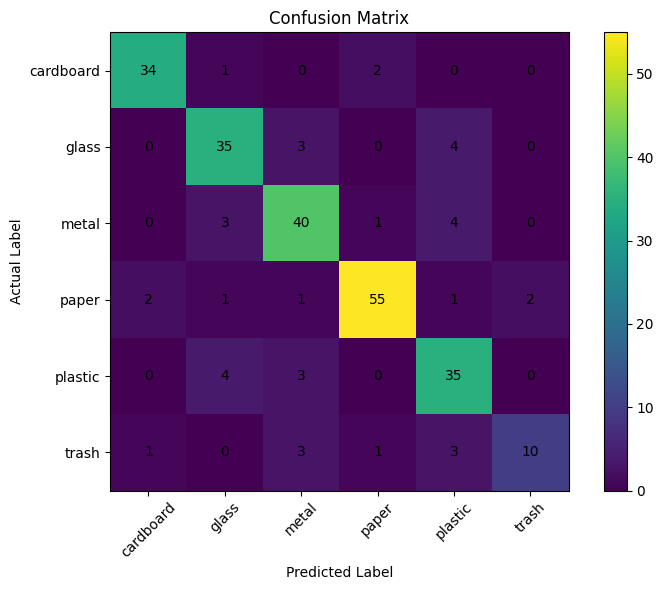

In [15]:
# ==========================================
# STEP 14: Confusion Matrix and
# Classification Report
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Actual labels aur predicted labels store karne ke liye lists
true_labels = []
predicted_labels = []

# Test dataset ki har batch par prediction karna
for images, labels in test_dataset:

    # Model se prediction lena
    predictions = model.predict(images, verbose=0)

    # Sabse high probability wali class select karna
    predicted_classes = np.argmax(predictions, axis=1)

    # Actual labels store karna
    true_labels.extend(labels.numpy())

    # Predicted labels store karna
    predicted_labels.extend(predicted_classes)

# ==========================================
# Classification Report
# ==========================================

print("Classification Report:\n")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix ko graph ke form mein display karna
plt.figure(figsize=(8, 6))

plt.imshow(cm)

# Color bar display karna
plt.colorbar()

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Graph title
plt.title("Confusion Matrix")

# Class names ko axes par display karna
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

# Har cell mein number display karna
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

# Layout adjust karna
plt.tight_layout()

# Graph show karna
plt.show()

Saving Screenshot (213).png to Screenshot (213).png


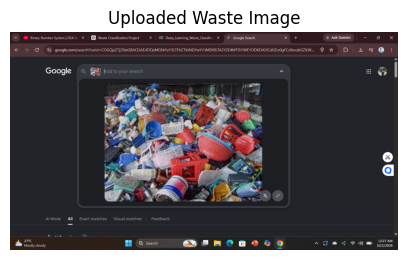

Predicted Waste Category: metal
Confidence: 44.13 %


In [16]:
# ==========================================
# STEP 15: Predict Waste Category
# from a New Image
# ==========================================

from google.colab import files
from PIL import Image
import numpy as np

# Laptop se image upload karna
uploaded = files.upload()

# Uploaded image ka naam lena
image_name = list(uploaded.keys())[0]

# Image open karna
image = Image.open(image_name).convert("RGB")

# Original image display karna
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Uploaded Waste Image")
plt.axis("off")
plt.show()

# Image ko model ke required size mein resize karna
image_resized = image.resize((224, 224))

# Image ko NumPy array mein convert karna
image_array = np.array(image_resized)

# Batch dimension add karna
# Shape: (224, 224, 3) → (1, 224, 224, 3)
image_array = np.expand_dims(image_array, axis=0)

# Model se prediction lena
prediction = model.predict(image_array, verbose=0)

# Highest probability wali class select karna
predicted_index = np.argmax(prediction[0])

# Predicted category
predicted_class = class_names[predicted_index]

# Prediction confidence
confidence = prediction[0][predicted_index] * 100

# Result display karna
print("Predicted Waste Category:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [17]:
# ==========================================
# STEP 16: Save the Trained Model
# ==========================================

# Trained model ko .keras format mein save karna
# Isse hum future mein model ko dobara use kar sakenge
model.save("/content/waste_classification_mobilenetv2.keras")

# Confirmation message
print("Model saved successfully!")

Model saved successfully!


In [18]:
# ==========================================
# STEP 17: Load and Verify Saved Model
# ==========================================

# Saved model ko file se dobara load karna
loaded_model = tf.keras.models.load_model(
    "/content/waste_classification_mobilenetv2.keras"
)

# Loaded model ki information display karna
print("Saved model loaded successfully!")

# Model ka summary check karna
loaded_model.summary()

Saved model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 1280)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 6)                │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,281,044 (8.70 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 15,374 (60.06 KB)

In [19]:
# ==========================================
# STEP 18: Test Prediction Using Saved Model
# ==========================================

# Saved model se uploaded image par prediction lena
saved_prediction = loaded_model.predict(
    image_array,
    verbose=0
)

# Highest probability wali class ka index find karna
saved_predicted_index = np.argmax(saved_prediction[0])

# Predicted waste category
saved_predicted_class = class_names[saved_predicted_index]

# Prediction confidence calculate karna
saved_confidence = saved_prediction[0][saved_predicted_index] * 100

# Final prediction display karna
print("Saved Model Prediction:", saved_predicted_class)

# Confidence display karna
print("Confidence:", round(saved_confidence, 2), "%")

Saved Model Prediction: metal
Confidence: 44.13 %


In [20]:
# ==========================================
# STEP 19: Display Final Project Results
# ==========================================

# Final test accuracy display karna
print("==========================================")
print("       WASTE CLASSIFICATION RESULTS")
print("==========================================")

print("Number of Classes:", len(class_names))

print("Waste Categories:")
for i, cls in enumerate(class_names):
    print(f"{i + 1}. {cls}")

print("\nTest Accuracy:", round(test_accuracy * 100, 2), "%")

print("Test Loss:", round(test_loss, 4))

print("\nModel: MobileNetV2")
print("Input Image Size: 224 x 224")
print("Training Epochs:", EPOCHS)

print("\nNew Image Prediction:")
print("Predicted Category:", saved_predicted_class)
print("Prediction Confidence:", round(saved_confidence, 2), "%")

print("\nModel saved and verified successfully!")

       WASTE CLASSIFICATION RESULTS
Number of Classes: 6
Waste Categories:
1. cardboard
2. glass
3. metal
4. paper
5. plastic
6. trash

Test Accuracy: 85.14 %
Test Loss: 0.4555

Model: MobileNetV2
Input Image Size: 224 x 224
Training Epochs: 15

New Image Prediction:
Predicted Category: metal
Prediction Confidence: 44.13 %

Model saved and verified successfully!


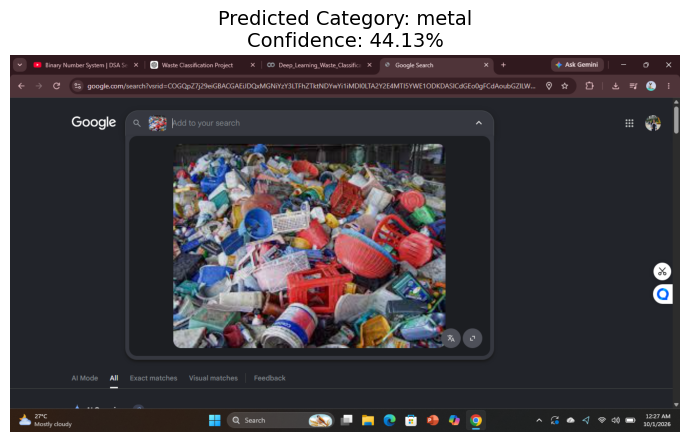

In [21]:
# ==========================================
# STEP 20: Final Prediction Visualization
# ==========================================

# Figure ka size set karna
plt.figure(figsize=(7, 6))

# Uploaded image display karna
plt.imshow(image)

# Prediction ko title mein show karna
plt.title(
    f"Predicted Category: {saved_predicted_class}\n"
    f"Confidence: {saved_confidence:.2f}%",
    fontsize=14
)

# Axis remove karna
plt.axis("off")

# Layout ko clean banana
plt.tight_layout()

# Final result display karna
plt.show()